# Évaluation des modèles et d’ajustement des hyperparamètres

CSI 4506 - Automne 2024

Marcel Turcotte  
Version: oct. 5, 2024 13h02

# Préambule

## Citation du jour

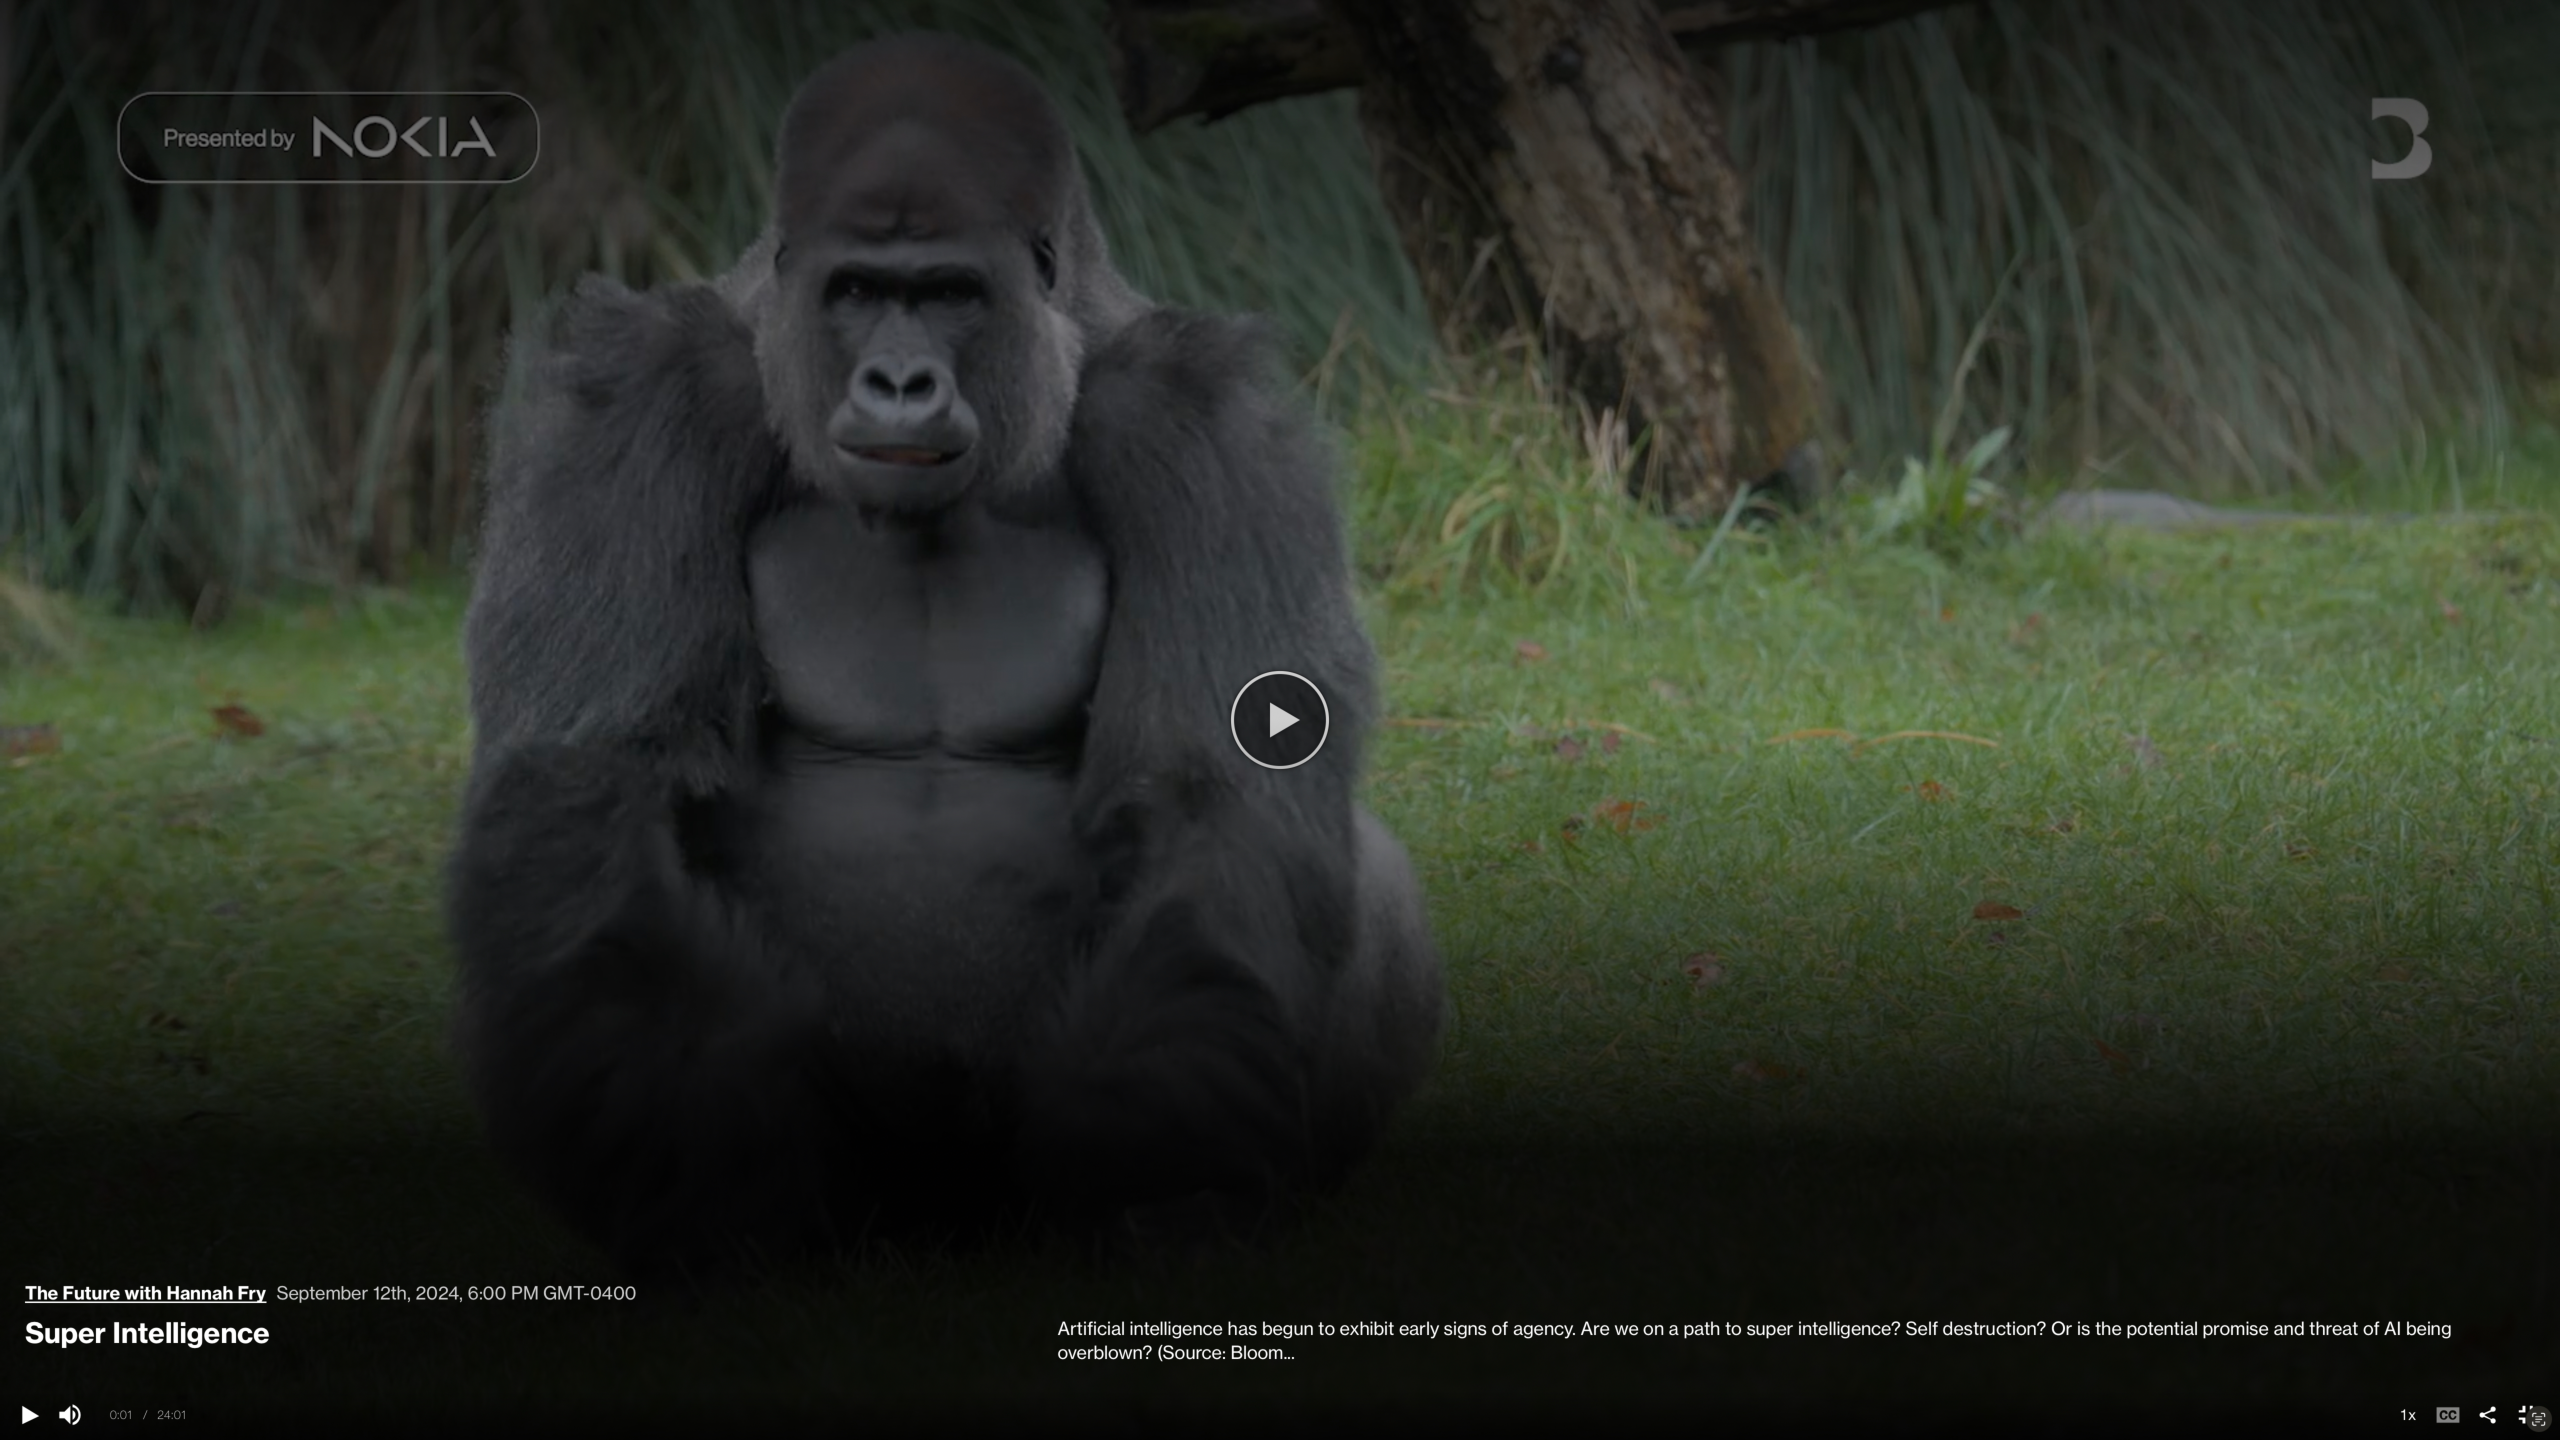

[Super
Intelligence](https://www.bloomberg.com/news/videos/2024-09-12/super-intelligence-the-future-with-hannah-fry-video)
tiré de [The Future with Hannah
Fry](https://www.bloomberg.com/originals/series/the-future-hannah-fry),
diffusé le 12 septembre 2024.

## Objectifs d’apprentissage

1.  **Comprendre l’objectif de la division des données :**
    -   Décrire les rôles des ensembles d’entraînement, de validation et
        de test dans l’évaluation des modèles.
    -   Expliquer pourquoi et comment les ensembles de données sont
        divisés pour un apprentissage et une évaluation efficaces des
        modèles.
2.  **Expliquer les techniques de validation croisée :**
    -   Définir la validation croisée et son importance dans
        l’évaluation des modèles.
    -   Illustrer le processus de validation croisée $k$-fold et ses
        avantages par rapport à une seule division entraînement-test.
    -   Discuter des concepts de sur-apprentissage et de
        sous-apprentissage dans le contexte de la validation croisée.
3.  **Ajustement des hyperparamètres :**
    -   Expliquer la différence entre les paramètres de modèle et les
        hyperparamètres.
    -   Décrire les méthodes de réglage des hyperparamètres, y compris
        la recherche en grille et la recherche aléatoire.
    -   Implémenter l’ajustement des hyperparamètres à l’aide de
        `GridSearchCV` dans scikit-learn.
4.  **Évaluer la performance du modèle :**
    -   Interpréter les résultats de la validation croisée et comprendre
        des métriques telles que la moyenne et l’écart-type des scores.
    -   Discuter de la manière dont la validation croisée aide à évaluer
        la généralisation du modèle et à réduire la variabilité.
5.  **Flux de travail de l’ingénierie en apprentissage automatique :**
    -   Décrire les étapes impliquées dans la préparation des données
        pour les modèles d’apprentissage automatique.
    -   Utiliser les pipelines scikit-learn pour un prétraitement
        efficace des données et un entraînement des modèles.
    -   Insister sur l’importance des transformations de données
        cohérentes entre les environnements d’entraînement et de
        production.
6.  **Évaluation critique des modèles d’apprentissage automatique :**
    -   Évaluer les limites et les défis liés à l’ajustement des
        hyperparamètres et à la sélection de modèles.
    -   Reconnaître les pièges potentiels dans le prétraitement des
        données, tels qu’une gestion incorrecte des valeurs manquantes
        ou un encodage incohérent.
    -   Plaider en faveur de tests et validations approfondis pour
        garantir la fiabilité et la généralisabilité du modèle.
7.  **Intégration des connaissances dans des applications pratiques :**
    -   Appliquer les concepts appris à des ensembles de données réels
        (par exemple, ensembles de données OpenML tels que ‘diabetes’ et
        ‘adult’).
    -   Interpréter et analyser les résultats des évaluations de modèles
        et des expériences.
    -   Développer une compréhension complète du pipeline
        d’apprentissage automatique de bout en bout.

Les objectifs d’apprentissage ci-haut ont été générés par le modèle
d’OpenAI, [o1](https://openai.com/index/introducing-openai-o1-preview/),
à partir du contenu du cours.

# Introduction

## Ensemble de données - openml

> ** [www.openml.org](https://www.openml.org)**
>
> OpenML est une plateforme ouverte pour partager des ensembles de
> données, des algorithmes et des expériences - pour apprendre à mieux
> apprendre, ensemble.

In [1]:
import numpy as np
np.random.seed(42)

from sklearn.datasets import fetch_openml

diabetes = fetch_openml(name='diabetes', version=1)
print(diabetes.DESCR)

L’ensemble de données utilisé aujourd’hui est le PIMA, qui contient 768
exemples et 8 attributs numériques. La nature numérique de ces attributs
facilite notre analyse. De plus, puisque les données proviennent d’un
article publié, elles reflètent probablement une collecte de données
soignée, ce qui pourrait conduire à des résultats robustes, étant donné
que les auteurs auraient eu besoin de données de haute qualité pour
étayer leur publication.

## Ensemble de données - `return_X_y`

`fetch_openml` renvoie un `Bunch`, un `DataFrame` ou `X` et `y`

In [2]:
X, y = fetch_openml(name='diabetes', version=1, return_X_y=True)

. . .

Déséquilibre modéré (rapport inférieur à 3 ou 4)

In [3]:
print(y.value_counts())

class
tested_negative    500
tested_positive    268
Name: count, dtype: int64

. . .

Conversion des étiquettes cibles en 0 et 1

In [4]:
y = y.map({'tested_negative': 0, 'tested_positive': 1})

# Évaluation croisée

## Ensemble d’entraînement et ensemble de test

Parfois appelée *holdout method*.

-   **Recommandation:** Allouer **80%** de votre ensemble de données
    pour **l’entraînement** et réserver les **20% restants** pour les
    tests.

-   **Ensemble d’entraînement:** Sous-ensemble de données utilisé pour
    **entraîner** votre modèle.

-   **Ensemble de test:** Sous-ensemble **indépendant** utilisé
    exclusivement lors de l’étape finale pour évaluer les performances
    du modèle.

### Ratios courants d’entraînement et de test

1.  **Division 80:20:**
    -   **Ensemble d’entraînement:** 80% des données
    -   **Ensemble de test:** 20% des données
    -   Ce partage est un choix par défaut largement utilisé qui permet
        un équilibre entre avoir suffisamment de données pour entraîner
        le modèle et suffisamment de données pour évaluer ses
        performances.
2.  **Division 90:10:**
    -   **Ensemble d’entraînement:** 90% des données
    -   **Ensemble de test:** 10% des données
    -   Ce partage peut être utilisé lorsque l’ensemble de données est
        très grand, garantissant une quantité substantielle de données
        pour l’entraînement tout en conservant un ensemble de test de
        taille décente.

### Considérations pour choisir le ratio

1.  **Taille de l’ensemble de données:**
    -   Pour les grands ensembles de données, une plus petite proportion
        peut être réservée aux tests (par exemple, 90:10), car même 10%
        d’un grand ensemble de données peut fournir une évaluation
        robuste.
2.  **Complexité du modèle:**
    -   Les modèles complexes avec de nombreux paramètres peuvent
        nécessiter davantage de données d’entraînement pour éviter le
        sur-apprentissage, suggérant un ensemble d’entraînement plus
        grand.
3.  **Ensemble de validation:**
    -   Voir la discussion ci-dessous.
4.  **Ensembles de données déséquilibrés:**
    -   Pour les ensembles de données déséquilibrés, il est essentiel de
        veiller à ce que les ensembles d’entraînement et de test
        représentent adéquatement la répartition des classes.
        **L’échantillonnage stratifié peut être utilisé pour maintenir
        les proportions de classes dans les deux ensembles.**

## Ensemble d’entraînement et ensemble de test

**Erreur d’entraînement :**

-   En général, elle a tendance à être **faible**
-   Obtenue en optimisant les algorithmes d’apprentissage pour minimiser
    l’erreur à travers l’ajustement des paramètres (par exemple, les
    poids)

## Ensemble d’entraînement et ensemble de test

**Erreur de généralisation :** L’erreur observée lorsque le modèle est
évalué sur des données nouvelles, non vues.

## Ensemble d’entraînement et ensemble de test

**Sous-apprentissage :**

-   **Erreur d’entraînement élevée**
-   Le modèle est trop simple pour capturer les motifs sous-jacents
-   Mauvaise performance à la fois sur les données d’entraînement et les
    nouvelles données

**Sur-apprentissage :**

-   Faible erreur d’entraînement, mais **erreur de généralisation
    élevée**
-   Le modèle capture le bruit ou des motifs non pertinents
-   Mauvaise performance sur les nouvelles données non vues

## Définition

**La validation croisée** (*cross-validation*) est une méthode utilisée
pour évaluer et améliorer les performances des modèles d’apprentissage
automatique.

Elle consiste à partitionner l’ensemble de données en plusieurs
sous-ensembles, **en entraînant le modèle sur certains sous-ensembles**
tout en **le validant sur les autres**.

## Validation croisée en $k$ parties (k-fold)

1.  **Diviser** l’ensemble de données en **$k$ parties de taille égale**
    (plis).
2.  **Entraînement et validation :**
    -   À chaque itération, **un pli est utilisé comme ensemble de
        validation**, les **$k$-1 plis restants sont utilisés comme
        ensemble d’entraînement**.
3.  **Évaluation:** Les performances du modèle sont évaluées à chaque
    itération, ce qui donne $k$ mesures de performance.
4.  **Agrégation:** Les statistiques sont calculées à partir des $k$
    mesures de performance.

Les choix courants pour la valeur de $k$ sont 3, 5, 7 et 10.

## Validation croisée en 3 plis

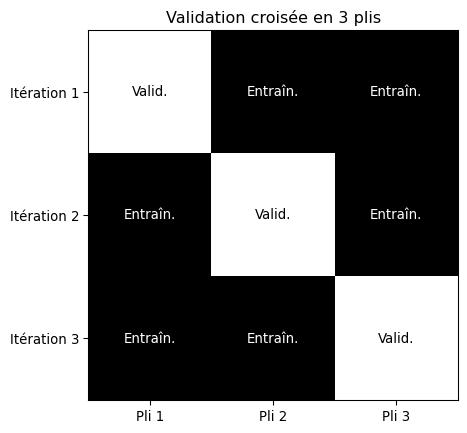

À chaque itération, $2/3$ de l’ensemble de données est utilisé pour
l’entraînement et $1/3$ pour la validation.

## Validation croisée en 5 plis

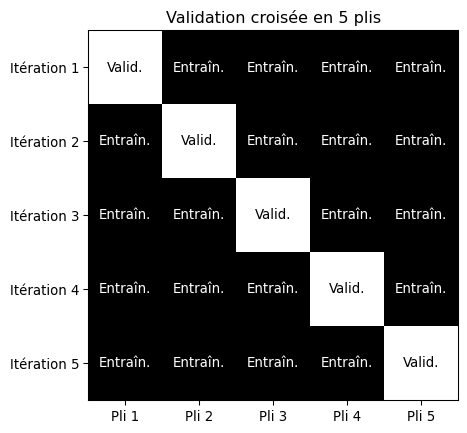

À chaque itération, $4/5$ de l’ensemble de données est utilisé pour
l’entraînement et $1/5$ pour la validation.

## Évaluation de modèle plus fiable

-   Estimation plus **fiable** des performances du modèle par rapport à
    une seule division entraînement-test.
-   **Réduit la variabilité** associée à une seule division, conduisant
    à une **évaluation plus stable et moins biaisée**.
-   Pour de grandes valeurs de $k$, considérez la **moyenne**,
    **variance**, et **intervalle de confiance**.

## Meilleure généralisation

-   Aide à évaluer comment le modèle **généralise** à un ensemble de
    données indépendant.
-   Garantit que les performances du modèle ne sont ni trop
    **optimistes** ni trop **pessimistes** en moyennant les résultats
    sur plusieurs plis.

## Utilisation efficace des données

-   **Particulièrement bénéfique pour les petits ensembles de données**,
    la validation croisée garantit que chaque point de données est
    utilisé à la fois pour l’entraînement et la validation.
-   Cela **maximise l’utilisation des données disponibles**, conduisant
    à un entraînement de modèle plus précis et fiable.

Certaines exemples sont plus informatifs pour les algorithmes
d’apprentissage, notamment ceux situés près de la frontière de décision.

## Ajustement des hyperparamètres

-   Couramment utilisé pendant **l’ajustement des hyperparamètres**,
    permettant de **sélectionner les meilleurs paramètres du modèle** en
    fonction de leurs performances sur plusieurs plis.
-   Cela aide à identifier la configuration **optimale** qui équilibre
    **biais** et **variance**.

## Défis

-   **Coût computationnel**: Nécessite plusieurs entraînements de
    modèles.
    -   **Leave-One-Out** (LOO): Cas extrême où $k = N$.
-   **Déséquilibre des classes**: Les plis peuvent ne pas représenter
    correctement les classes minoritaires.
    -   Utilisez la **validation croisée stratifiée** pour maintenir les
        proportions de classes.
-   **Complexité**: Implémentation sujette à des erreurs, en particulier
    pour la **validation croisée imbriquée**, les **bootstrap** ou
    l’intégration dans des pipelines plus complexes.

La validation croisée leave-one-out (LOO-CV) peut conduire à une
évaluation de performance trop optimiste, particulièrement dans certains
contextes.

Voici pourquoi :

1.  **Haute variance** : Dans la LOO-CV, chaque itération utilise
    presque toutes les données pour l’entraînement, ne laissant qu’une
    seule instance pour le test. Cela peut entraîner une haute variance
    de l’erreur de test à travers les itérations, car le modèle est
    entraîné sur presque l’ensemble du jeu de données. Étant donné que
    chaque ensemble d’entraînement est très similaire au jeu de données
    complet, cela peut conduire à des estimations trop optimistes de
    l’erreur de généralisation, surtout lorsque le jeu de données est
    petit ou que le modèle a une variance élevée (par exemple, les
    arbres de décision ou les k-plus proches voisins).

2.  **Surapprentissage** : Comme la LOO-CV utilise presque l’intégralité
    du jeu de données pour l’entraînement à chaque itération, les
    modèles complexes (surtout ceux sujets au surapprentissage) peuvent
    s’ajuster très étroitement aux données, ce qui peut résulter en une
    erreur d’entraînement faible mais en une erreur de test
    trompeusement faible dans certains cas.

3.  **Évaluation limitée de la généralisation** : La LOO-CV peut ne pas
    fournir une estimation fiable de la capacité de généralisation du
    modèle à des données complètement nouvelles, car la différence entre
    l’ensemble d’entraînement et le jeu de données complet est minimale,
    ce qui réduit l’écart entre les performances d’entraînement et de
    test.

En pratique, cela peut rendre l’évaluation plus optimiste qu’elle ne le
serait avec des méthodes plus robustes comme la validation croisée
k-fold, où les ensembles de test sont plus grands et où le modèle a
moins d’opportunités de surapprendre les données d’entraînement.

## `cross_val_score`

In [8]:
from sklearn import tree

clf = tree.DecisionTreeClassifier()

from sklearn.model_selection import cross_val_score    

clf_scores = cross_val_score(clf, X, y, cv=5)

print("\nScores:", clf_scores)
print(f"\nMoyenne: {clf_scores.mean():.2f}")
print(f"\nÉcart-type: {clf_scores.std():.2f}")


Scores: [0.71428571 0.66883117 0.71428571 0.79738562 0.73202614]

Moyenne: 0.73

Écart-type: 0.04

[sklearn.model_selection.cross_val_score](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html),
voir aussi
[cross_validate](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html#sklearn.model_selection.cross_validate).

Comme discuté précédemment, une limitation significative des arbres de
décision est leur tendance à **sur-apprendre**, ce qui conduit à une
forte variance lorsqu’ils sont appliqués à de nouveaux ensembles de
données. Ce problème est visible dans la variabilité des performances
observée, avec une précision allant de 67% à 79%, ce qui est indésirable
pour obtenir une généralisation robuste du modèle.

# Ajustement des hyperparamètres

## Flux de travail (*Workflow*)

![](https://scikit-learn.org/stable/_images/grid_search_workflow.png)

**Attribution**: [Cross-validation: evaluating estimator
performance](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation)

L’image ci-dessus introduit implicitement trois catégories de
sous-ensembles de données : **entraînement**, **validation**, et
**test**.

## Implémentation du flux de travail

In [9]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml(name='diabetes', version=1, return_X_y=True)

y = y.map({'tested_negative': 0, 'tested_positive': 1})

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

Afin de simplifier ces notes de cours, nous n’avons appliqué aucune
étape de prétraitement.

## Définition

Un **hyperparamètre** est une configuration **externe au modèle** qui
est **définie avant le processus d’apprentissage** et qui régit le
processus d’apprentissage, influençant les performances et la complexité
du modèle.

Les **poids d’un modèle**, qui sont appris par l’algorithme
d’apprentissage, sont souvent appelés **paramètres du modèle**. Pour
éviter toute confusion, les paramètres définis par l’utilisateur, tels
que le taux d’apprentissage $\alpha$, sont appelés **hyperparamètres**.
Contrairement aux paramètres de modèle, les hyperparamètres ne sont
**pas** appris par l’algorithme d’apprentissage.

## Hyperparamètres - Arbre de décision

-   `criterion`: `gini`, `entropy`, `log_loss`, mesure la qualité d’une
    scission.
-   `max_depth`: limite le **nombre de niveaux** dans l’arbre pour
    éviter le sur-apprentissage.

**Voir**:
[DecisionTreeClassifier](https://scikit-learn.org/dev/modules/generated/sklearn.tree.DecisionTreeClassifier.html)

## Hyperparamètres - Régression logistique

-   `penalty`: `l1` ou `l2`, aide à éviter le sur-apprentissage.
-   `solver`: `liblinear`, `newton-cg`, `lbfgs`, `sag`, `saga`.
-   `max_iter`: nombre maximal d’itérations pour que les solveurs
    convergent.
-   `tol`: critère d’arrêt, les petites valeurs signifient une plus
    grande précision.

**Voir**:
[LogisticRegression](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html)
et
[SGDClassifier](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.SGDClassifier.html).

## Hyperparamètres - KNN

-   `n_neighbors`: nombre de voisins à utiliser pour les requêtes de
    $k$-voisins.
-   `weights`: `uniform` ou `distance`, poids égal ou basé sur la
    distance.

**Voir**:
[KNeighborsClassifier](https://scikit-learn.org/dev/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)

## Expérience : `max_depth`

In [10]:
for value in [3, 5, 7, None]:

  clf = tree.DecisionTreeClassifier(max_depth=value)

  clf_scores = cross_val_score(clf, X_train, y_train, cv=10)

  print("\nmax_depth = ", value)
  print(f"Moyenne: {clf_scores.mean():.2f}")
  print(f"Écart-type: {clf_scores.std():.2f}")


max_depth =  3
Moyenne: 0.74
Écart-type: 0.04

max_depth =  5
Moyenne: 0.76
Écart-type: 0.04

max_depth =  7
Moyenne: 0.73
Écart-type: 0.04

max_depth =  None
Moyenne: 0.71
Écart-type: 0.05

## Expérience : `criterion`

In [11]:
for value in ["gini", "entropy", "log_loss"]:

  clf = tree.DecisionTreeClassifier(max_depth=5, criterion=value)

  clf_scores = cross_val_score(clf, X_train, y_train, cv=10)

  print("\ncriterion = ", value)
  print(f"Moyenne: {clf_scores.mean():.2f}")
  print(f"Écart-type: {clf_scores.std():.2f}")


criterion =  gini
Moyenne: 0.76
Écart-type: 0.04

criterion =  entropy
Moyenne: 0.75
Écart-type: 0.05

criterion =  log_loss
Moyenne: 0.75
Écart-type: 0.05

Pour ce problème et cet ensemble de données spécifiques, le paramètre
`criterion` a un impact limité sur le processus d’apprentissage.

## Expérience : `n_neighbors`

In [12]:
from sklearn.neighbors import KNeighborsClassifier

for value in range(1, 11):

  clf = KNeighborsClassifier(n_neighbors=value)

  clf_scores = cross_val_score(clf, X_train, y_train, cv=10)

  print("\nn_neighbors = ", value)
  print(f"Moyenne: {clf_scores.mean():.2f}")
  print(f"Écart-type: {clf_scores.std():.2f}")


n_neighbors =  1
Moyenne: 0.67
Écart-type: 0.05

n_neighbors =  2
Moyenne: 0.71
Écart-type: 0.03

n_neighbors =  3
Moyenne: 0.69
Écart-type: 0.05

n_neighbors =  4
Moyenne: 0.73
Écart-type: 0.03

n_neighbors =  5
Moyenne: 0.72
Écart-type: 0.03

n_neighbors =  6
Moyenne: 0.73
Écart-type: 0.05

n_neighbors =  7
Moyenne: 0.74
Écart-type: 0.04

n_neighbors =  8
Moyenne: 0.75
Écart-type: 0.04

n_neighbors =  9
Moyenne: 0.73
Écart-type: 0.05

n_neighbors =  10
Moyenne: 0.73
Écart-type: 0.04

## Expérience : `weights`

In [13]:
from sklearn.neighbors import KNeighborsClassifier

for value in ["uniform", "distance"]:

  clf = KNeighborsClassifier(n_neighbors=5, weights=value)

  clf_scores = cross_val_score(clf, X_train, y_train, cv=10)

  print("\nweights = ", value)
  print(f"Moyenne: {clf_scores.mean():.2f}")
  print(f"Écart-type: {clf_scores.std():.2f}")


weights =  uniform
Moyenne: 0.72
Écart-type: 0.03

weights =  distance
Moyenne: 0.73
Écart-type: 0.04

Pour ce problème et cet ensemble de données spécifiques, le paramètre
`weights` a un impact limité sur le processus d’apprentissage.

À ce stade, vous pourriez émettre l’hypothèse que certaines combinaisons
d’hyperparamètres pourraient être plus optimales que d’autres.

## Recherche en grille (*grid search*)

-   **De nombreux hyperparamètres** nécessitent un ajustement

    -   Principal **désavantage** des algorithmes d’apprentissage
        automatique

-   L’**exploration manuelle** des combinaisons est fastidieuse

-   La **recherche en grille** est plus systématique

    1.  **Énumérer toutes** les combinaisons possibles d’hyperparamètres

    2.  Entraîner sur l’ensemble d’entraînement, évaluer sur l’ensemble
        de validation

**Initialement**, essayez des puissances de 2 ou de 10. Ensuite,
**affinez** avec une recherche en grille autour des valeurs optimales si
le temps le permet.

L’**ensemble d’entraînement** mentionné ici est **différent** de celui
mentionné précédemment. À chaque itération du processus de validation
croisée en $k$ plis, un **ensemble d’entraînement** et un **ensemble de
validation** uniques sont créés.

Dans certains contextes, le **choix du modèle** lui-même peut être
considéré comme un hyperparamètre. Par exemple, lors de la sélection de
modèles au sein d’un pipeline d’apprentissage automatique, différents
algorithmes (par exemple, arbres de décision, machines à vecteurs de
support, réseaux neuronaux) peuvent être traités comme des
hyperparamètres. Cela permet de sélectionner le modèle offrant les
meilleures performances via des processus automatisés comme la recherche
en grille ou la recherche aléatoire, en parallèle du réglage d’autres
hyperparamètres.

Ainsi, bien que traditionnellement les hyperparamètres fassent référence
aux paramètres à l’intérieur d’un modèle spécifique, le choix du modèle
peut également être intégré dans des cadres d’optimisation
d’hyperparamètres.

## `GridSearchCV`

In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = [
  {'max_depth': range(1, 10),
   'criterion': ["gini", "entropy", "log_loss"]}
]

clf = tree.DecisionTreeClassifier()

grid_search = GridSearchCV(clf, param_grid, cv=5)

grid_search.fit(X_train, y_train)

(grid_search.best_params_, grid_search.best_score_)

({'criterion': 'gini', 'max_depth': 5}, 0.7481910124074653)

## `GridSearchCV`

In [15]:
param_grid = [
  {'n_neighbors': range(1, 16),
   'weights': ["uniform", "distance"]}
]

clf = KNeighborsClassifier()

grid_search = GridSearchCV(clf, param_grid, cv=5)

grid_search.fit(X_train, y_train)

(grid_search.best_params_, grid_search.best_score_)

({'n_neighbors': 14, 'weights': 'uniform'}, 0.7554165363361485)

La variable `param_grid` contient un dictionnaire spécifiant les noms
des paramètres à ajuster, ainsi que les valeurs respectives à tester.

Dans cet exemple, les paramètres `n_neighbors` et `weights` sont
ajustés. Cependant, d’autres paramètres pourraient être inclus si
nécessaire.

## `GridSearchCV`

In [17]:
from sklearn.linear_model import LogisticRegression

# 2 * 5 * 5 * 3 = 150 tests!

param_grid = [
  {'penalty': ["l1", "l2", None],
   'solver' : ['liblinear', 'newton-cg', 'lbfgs', 'sag', 'saga'],
   'max_iter' : [100, 200, 400, 800, 1600],
   'tol' : [0.01, 0.001, 0.0001]}
]

clf = LogisticRegression()

grid_search = GridSearchCV(clf, param_grid, cv=5)

grid_search.fit(X_train, y_train)

(grid_search.best_params_, grid_search.best_score_)

({'max_iter': 100, 'penalty': 'l2', 'solver': 'newton-cg', 'tol': 0.001},
 0.7756646856427901)

## Recherche aléatoire

-   **Grand nombre de combinaisons** (beaucoup d’hyperparamètres,
    beaucoup de valeurs)
-   Utiliser **RandomizedSearchCV** :
    -   Fournir une **liste de valeurs** ou une **distribution de
        probabilités** pour les hyperparamètres
    -   Spécifier le **nombre d’itérations** (combinaisons à essayer)
    -   Temps d’exécution **prévisible**

**Voir** : [Comparing randomized search and grid search for
hyperparameter
estimation](https://scikit-learn.org/stable/auto_examples/model_selection/plot_randomized_search.html).

## Flux de travail

![](https://scikit-learn.org/stable/_images/grid_search_workflow.png)

**Attribution**: [Cross-validation: evaluating estimator
performance](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation)

Comme l’illustre cet exemple, en plus d’évaluer diverses valeurs
d’hyperparamètres, plusieurs modèles peuvent également être testés.

## Enfin, nous procédons aux tests

In [18]:
clf = LogisticRegression(max_iter=100, penalty='l2', solver='newton-cg', tol=0.001)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.83      0.83        52
           1       0.64      0.64      0.64        25

    accuracy                           0.77        77
   macro avg       0.73      0.73      0.73        77
weighted avg       0.77      0.77      0.77        77


Il semble que nous soyons confrontés à un **problème de déséquilibre des
classes**, qui aurait dû être identifié plus tôt dans notre flux de
travail!

# Prologue

## Résumé

-   **Validation croisée et ajustement des hyperparamètres** : Clé pour
    prévenir le surapprentissage et optimiser les performances.

## Prochain cours

-   Ingénierie de l’apprentissage automatique.

## Références

Russell, Stuart, et Peter Norvig. 2020. *Artificial Intelligence: A
Modern Approach*. 4ᵉ éd. Pearson. <http://aima.cs.berkeley.edu/>.

------------------------------------------------------------------------

Marcel **Turcotte**

<Marcel.Turcotte@uOttawa.ca>

École de **science informatique** et de génie électrique (**SI**GE)

Université d’Ottawa